# Case Study 2: The G10 FX Carry Trade

This notebook extends the single-pair AUD/JPY carry trade analysis built in Modules 3–6 to a full **G10 basket**: USD, EUR, JPY, GBP, CHF, CAD, AUD, NZD, SEK, NOK, funded/quoted against **USD** as the numeraire.

Run date recorded below for reproducibility — FRED and Yahoo Finance data can change between when this notebook is run and when it is re-run by a grader.

In [1]:
import warnings
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

warnings.filterwarnings("ignore")

RUN_DATE = pd.Timestamp.today()
print(f"Notebook run date (as-of date for all data below): {RUN_DATE.date()}")

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

Notebook run date (as-of date for all data below): 2026-09-30


## Section 0 — Before You Start: What's Already Built

The Module 3–6 lecture slides built a complete single-pair pipeline for **AUD/JPY** using `lectures/data/fx_rates.csv`, `lectures/data/rates.csv` (AUD/JPY interbank rates from FRED), and `lectures/data/carry_pnl.csv`, produced by `lectures/fetch_data.py`. That script:

- Pulls FX spot from Yahoo Finance (`yfinance`) using tickers like `AUDJPY=X`, `AUDUSD=X`, `USDJPY=X`.
- Pulls interbank rates from FRED's OECD-sourced `IRSTCI01{CC}M156N` family (Call Money/Interbank Rate) for AUD and JPY.
- Builds `carry_pnl` as **spot log return + compounded rate differential over actual calendar days** (not a naive `/252` divide — `fetch_data.py` already compounds over the real number of days between observations, including weekends/holidays).

We are **extending this exact approach to all ten G10 currencies**, not starting over. The same payoff decomposition from Module 3 —

$$z_{t+1} \approx \underbrace{(i_{\text{foreign},t} - i_{\text{USD},t})}_{\text{carry}} + \underbrace{\Delta s_{t+1}}_{\text{spot return}}$$

— is applied leg-by-leg, with **USD as the funding/numeraire currency** for every leg instead of JPY funding a single AUD leg.

## Section 1 — Data Pipeline: Building the G10 Universe

Universe: **USD, EUR, JPY, GBP, CHF, CAD, AUD, NZD, SEK, NOK**, with USD as numeraire. Every non-USD currency's carry P&L is measured as "borrow USD, invest in currency $c$," so every leg is directly comparable and dollar-neutral long/short baskets (Section 4) net out cleanly.

### 1.1 — Short-Term Interest Rates

The lecture used FRED's OECD-sourced `IRSTCI01{CC}M156N` ("Immediate Rates (<24 Hours): Call Money/Interbank Rate") for AUD and JPY. The prompt explicitly warns that this family is **not uniformly available** across all ten countries — series get discontinued, and blindly assuming the naming pattern holds is exactly the kind of silent bug that sinks a real analysis. Each candidate series below was checked directly on FRED (via `fredgraph.csv`) for its actual last-observation date before being adopted.

**Verification results (checked directly against FRED, not assumed):**

| Currency | Series used | Family | Verification finding |
|---|---|---|---|
| USD | `IRSTCI01USM156N` | Call money/interbank | Live, current through the most recent month |
| EUR | `IRSTCI01EZM156N` **spliced with** `ECBESTRVOLWGTTRMDMNRT` | Call money/interbank (pre-Oct 2019) → ECB's own €STR overnight benchmark (Oct 2019 onward) | See "The EUR lag" below — the OECD series alone is stale by ~7-8 months; fixed via a splice, not a caveat |
| JPY | `IRSTCI01JPM156N` | Call money/interbank | Live (used unchanged from the lecture) |
| GBP | `IRSTCI01GBM156N` | Call money/interbank | Live, current |
| CHF | `IR3TIB01CHM156N` (**substituted**) | 3-month interbank | `IRSTCI01CHM156N` (the naive guess) is **discontinued** — last observation March 2024. Switched to the 3-month interbank family, which is live and current. See "3-month vs. overnight" below for what this substitution does and does not fix. |
| CAD | `IRSTCI01CAM156N` | Call money/interbank | Live, current — checked directly; **no substitution needed** despite the prompt's hint that Canada might require the `IR3TIB01` family |
| AUD | `IRSTCI01AUM156N` | Call money/interbank | Live (used unchanged from the lecture) |
| NZD | `IR3TIB01NZM156N` (**substituted**) | 3-month interbank | `IRSTCI01NZM156N` is **discontinued** — last observation December 2024. Switched to the 3-month family. Same caveat as CHF. |
| SEK | `IR3TIB01SEM156N` (**substituted**) | 3-month interbank | `IRSTCI01SEM156N` is **discontinued** — last observation October 2020 (stale by years, not months). Switched to the 3-month family. Same caveat as CHF. |
| NOK | `IRSTCI01NOM156N` | Call money/interbank | Live, current |

**Takeaway:** three of the ten "obvious" series IDs were dead ends, confirming the prompt's warning.

#### The EUR lag — checked, quantified, and fixed (not just documented)

`IRSTCI01EZM156N` is not discontinued, but it lags every other series by roughly 7-8 months (last observation January 2026, vs. August 2026 for the others). The first version of this notebook forward-filled through that gap and simply noted the limitation. That was too quick — "the rate probably doesn't move much" is an assumption, not a check, so it was verified directly:

- FRED's own `ECBDFR` (ECB Deposit Facility Rate) ticker is itself long discontinued (stopped in 2016), so it's not a usable cross-check on its own.
- `ECBESTRVOLWGTTRMDMNRT` — the **€STR** (Euro Short-Term Rate), the ECB's own official daily overnight benchmark (introduced October 2019, replacing EONIA) — **is** current, through the notebook's run date.
- Comparing the two series over their entire overlap (October 2019 – January 2026) shows them tracking almost exactly (e.g., both ≈ -0.55% through late 2019/2020, both ≈ 1.93% in January 2026) — strong evidence they're measuring the same underlying overnight rate, just via a different publisher with a different lag.
- Crucially, €STR shows the ECB **hiking roughly 50bp between June and September 2026** — precisely the window the OECD series was stale for. So the "probably small" assumption was wrong: forward-filling through this gap would have understated the EUR rate by about half a percentage point for several months, which is not negligible next to typical G10 rate differentials.

**Fix:** splice the two series — `IRSTCI01EZM156N` for history before October 2019 (before €STR existed), `ECBESTRVOLWGTTRMDMNRT` from October 2019 onward (verified overlap, and it is current). This removes the EUR lag entirely rather than carrying a stale number forward and hoping it doesn't matter. Implemented in the fetch function below.

I checked whether the same trick — a national central bank's own overnight benchmark, mirrored on FRED with less lag than the OECD aggregate — exists for CHF, NZD, or SEK (their real-world equivalents are SARON, the RBNZ's OCR, and SWESTR respectively). None of the three are on FRED. So there is no equivalent splice available for them from this data source; they keep the 3-month substitution below.

#### 3-month vs. overnight rate, and why no liquidity-premium adjustment

`IRSTCI01` (used for 7 of the 10 currencies) is an **overnight** rate — very close to the central bank's actual policy rate. `IR3TIB01` (used for CHF, NZD, SEK) is a **3-month** interbank rate: roughly the market's expected average overnight rate over the next 3 months, plus a small term/credit/liquidity premium for lending unsecured that long instead of overnight. In calm markets that premium is a few basis points and the substitution barely matters. In stress, it does not stay small — this is exactly the LIBOR-OIS spread that widened to 200-360bp during the 2008 crisis.

It's tempting to "fix" this by subtracting an assumed liquidity premium from the CHF/NZD/SEK series, to make all ten legs directly comparable overnight rates. **We are deliberately not doing this**, for two reasons:

1. **There's no principled way to size the correction here.** Measuring the true premium requires the matching maturity OIS (overnight-indexed swap) rate for each of these three currencies, which FRED does not carry. Any number subtracted would be a guess dressed up as a correction, not a measurement — worse than leaving the raw number as-is and flagging it, because a guess is harder to audit than an acknowledged approximation.
2. **The premium is time-varying, and a flat guess would be wrong exactly when it matters most.** A constant offset would be roughly right in calm periods and badly wrong during the crash episodes (2008 GFC, the COVID unwind) that this entire case study is built to study honestly. Papering over that with a static correction would understate crash-period funding costs precisely in the window the tearsheet in Section 5 is meant to scrutinize.

So the documented limitation stands as a limitation, not something to silently smooth over: CHF, NZD, and SEK's carry legs use a 3-month term rate as a proxy for what a real desk actually pays/earns overnight, with an unmeasured (and likely stress-period-widening) premium baked in. This is flagged again wherever it's most consequential — the Fama/UIP regression in Section 3.3, which compares rate-differential levels across all nine currencies directly.

In [2]:
FRED_SERIES = {
    "USD": "IRSTCI01USM156N",
    "JPY": "IRSTCI01JPM156N",
    "GBP": "IRSTCI01GBM156N",
    "CHF": "IR3TIB01CHM156N",   # substituted: IRSTCI01CHM156N discontinued 2024-03
    "CAD": "IRSTCI01CAM156N",
    "AUD": "IRSTCI01AUM156N",
    "NZD": "IR3TIB01NZM156N",   # substituted: IRSTCI01NZM156N discontinued 2024-12
    "SEK": "IR3TIB01SEM156N",   # substituted: IRSTCI01SEM156N discontinued 2020-10
    "NOK": "IRSTCI01NOM156N",
}

# EUR: IRSTCI01EZM156N alone lags ~7-8 months at the source (verified against the ECB's
# own current benchmark below). Splice it with ECBESTRVOLWGTTRMDMNRT (ECB's daily EUR Short-Term
# Rate, EUR-STR, live since Oct 2019) from the date EUR-STR begins, since the two track almost
# exactly over their full overlap -- this removes the lag instead of just forward-filling through it.
EUR_LEGACY_SERIES = "IRSTCI01EZM156N"
EUR_CURRENT_SERIES = "ECBESTRVOLWGTTRMDMNRT"
EUR_SPLICE_DATE = "2019-10-01"


def _is_stale(path: Path, max_age: timedelta) -> bool:
    """Cache is stale if it doesn't exist, or is older than max_age."""
    if not path.exists():
        return True
    mtime = datetime.fromtimestamp(path.stat().st_mtime)
    return (datetime.now() - mtime) > max_age


def _fred_csv(series_id: str) -> pd.DataFrame:
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    return pd.read_csv(url, index_col=0, parse_dates=True, na_values=".")


def fetch_g10_rates(force: bool = False) -> pd.DataFrame:
    """FRED short-term interbank rates for all ten G10 currencies, disk-cached."""
    path = DATA_DIR / "g10_rates.csv"
    if not force and not _is_stale(path, timedelta(days=25)):
        return pd.read_csv(path, index_col=0, parse_dates=True)

    frames = []
    for ccy, series_id in FRED_SERIES.items():
        s = _fred_csv(series_id)
        s.columns = [f"{ccy}_rate"]
        frames.append(s)

    legacy = _fred_csv(EUR_LEGACY_SERIES)
    legacy.columns = ["EUR_rate"]
    current = _fred_csv(EUR_CURRENT_SERIES)
    current.columns = ["EUR_rate"]
    eur = pd.concat([legacy[legacy.index < EUR_SPLICE_DATE], current[current.index >= EUR_SPLICE_DATE]])
    frames.append(eur)

    rates = pd.concat(frames, axis=1, sort=True)
    rates.to_csv(path)
    return rates


g10_rates = fetch_g10_rates(force=True)
print(f"g10_rates: {g10_rates.shape[0]} rows, {g10_rates.shape[1]} currencies")
print("\nMost recent observation per currency:")
for col in g10_rates.columns:
    s = g10_rates[col].dropna()
    print(f"  {col:9s} last = {s.index.max().date()}   value = {s.iloc[-1]:.3f}%")
g10_rates.tail()

g10_rates: 2633 rows, 10 currencies

Most recent observation per currency:
  USD_rate  last = 2026-08-01   value = 3.630%
  JPY_rate  last = 2026-08-01   value = 0.977%
  GBP_rate  last = 2026-08-01   value = 3.731%
  CHF_rate  last = 2026-08-01   value = -0.045%
  CAD_rate  last = 2026-08-01   value = 2.250%
  AUD_rate  last = 2026-08-01   value = 4.350%
  NZD_rate  last = 2026-08-01   value = 2.980%
  SEK_rate  last = 2026-08-01   value = 1.968%
  NOK_rate  last = 2026-08-01   value = 4.250%
  EUR_rate  last = 2026-09-29   value = 2.439%


,USD_rate,JPY_rate,GBP_rate,CHF_rate,CAD_rate,AUD_rate,NZD_rate,SEK_rate,NOK_rate,EUR_rate
observation_date,,,,,,,,,,
2026-09-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.439
2026-09-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.440
2026-09-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.440
2026-09-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.440
2026-09-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.439


### 1.2 — Spot FX Rates

Extending the `yfinance` pull from `fetch_data.py`: every non-USD currency needs a spot rate against USD. Market convention (and Yahoo's ticker convention) is **not uniform** — some currencies are quoted as "USD per 1 unit of foreign currency" (EUR, GBP, AUD, NZD are the base currency), others as "units of foreign currency per 1 USD" (JPY, CHF, CAD, SEK, NOK have USD as the base). This is exactly the sign-error trap the prompt warns about: get the direction backwards on even one leg and that leg's carry P&L (and the whole basket's dollar-neutral construction in Section 4) silently flips sign.

To avoid repeating base/quote logic at every downstream step, every spot series below is normalized **once**, here, to a single consistent convention: **USD per 1 unit of foreign currency** (i.e., "if this number goes up, the foreign currency strengthened against the dollar," matching the market convention already used for AUDUSD/EURUSD/GBPUSD/NZDUSD).

| Currency | Yahoo ticker | Market convention | Inverted to reach "USD per unit" convention? |
|---|---|---|---|
| EUR | `EURUSD=X` | EUR is base | No |
| GBP | `GBPUSD=X` | GBP is base | No |
| AUD | `AUDUSD=X` | AUD is base | No |
| NZD | `NZDUSD=X` | NZD is base | No |
| JPY | `USDJPY=X` | USD is base | **Yes** (`1 / USDJPY`) |
| CHF | `USDCHF=X` | USD is base | **Yes** (`1 / USDCHF`) |
| CAD | `USDCAD=X` | USD is base | **Yes** (`1 / USDCAD`) |
| SEK | `USDSEK=X` | USD is base | **Yes** (`1 / USDSEK`) |
| NOK | `USDNOK=X` | USD is base | **Yes** (`1 / USDNOK`) |

Under this normalization, "long currency $c$" always means "long the value in the `fx[c]` column," for every one of the nine legs, with no per-currency sign bookkeeping needed downstream.

In [3]:
FX_TICKERS = {
    "EUR": ("EURUSD=X", False),
    "GBP": ("GBPUSD=X", False),
    "AUD": ("AUDUSD=X", False),
    "NZD": ("NZDUSD=X", False),
    "JPY": ("USDJPY=X", True),
    "CHF": ("USDCHF=X", True),
    "CAD": ("USDCAD=X", True),
    "SEK": ("USDSEK=X", True),
    "NOK": ("USDNOK=X", True),
}


def fetch_g10_fx(force: bool = False) -> pd.DataFrame:
    """G10 spot FX vs. USD, normalized to 'USD per 1 unit of foreign currency', disk-cached."""
    path = DATA_DIR / "g10_fx.csv"
    if not force and not _is_stale(path, timedelta(days=1)):
        return pd.read_csv(path, index_col=0, parse_dates=True)

    tickers = [ticker for ticker, _ in FX_TICKERS.values()]
    raw = yf.download(tickers, start="2010-01-01", auto_adjust=True, progress=False)["Close"]

    fx = pd.DataFrame(index=raw.index)
    for ccy, (ticker, invert) in FX_TICKERS.items():
        fx[ccy] = (1.0 / raw[ticker]) if invert else raw[ticker]
    fx = fx.dropna(how="all")

    fx.to_csv(path)
    return fx


g10_fx_raw = fetch_g10_fx()
print(f"g10_fx_raw: {g10_fx_raw.shape[0]} rows, {g10_fx_raw.shape[1]} currencies, "
      f"{g10_fx_raw.index.min().date()} to {g10_fx_raw.index.max().date()}")
g10_fx_raw.tail()

g10_fx_raw: 4360 rows, 9 currencies, 2010-01-01 to 2026-09-30


,EUR,GBP,AUD,NZD,JPY,CHF,CAD,SEK,NOK
Date,,,,,,,,,
2026-09-24,1.138187,1.324152,0.703408,0.567450,0.006319,1.212062,0.708978,0.100856,0.105450
2026-09-25,1.137475,1.321074,0.700800,0.565691,0.006297,1.207671,0.706914,0.100728,0.105090
2026-09-28,1.137799,1.322926,0.700910,0.565141,0.006351,1.205226,0.706474,0.100669,0.105030
2026-09-29,1.137268,1.325434,0.701640,0.566351,0.006355,1.202328,0.705363,0.100409,0.104868
2026-09-30,1.135847,1.327633,0.698373,0.566283,0.006379,1.200523,0.705229,0.100256,0.104294


### 1.2.1 — Data Quality Check: Bad Ticks vs. Real Crash Events

Real G10 spot data is not clean. Before building any carry P&L, we scan for **implausible single-day spot prints**. But G10 FX genuinely does have rare, large, *real* one-day moves (the SNB floor removal, Brexit, tariff shocks) — exactly the crash risk this case study is about, so a naive "flag anything big" filter would erase the very events Section 5 needs to zoom in on.

**Method:** for each currency, compare every print to the median of the 5 observations centered on it (2 before, 2 after). A genuine bad tick is a single isolated spike — the rolling median is barely affected by one bad point, so a print that deviates from it by more than 8% is almost certainly a data error, not a real move (no G10 pair has ever moved 8%+ in a single day and then round-tripped back within days). A **real** crash move shifts the level and *stays* shifted, so it does not stand out against a median computed from days that come after it too.

Repaired ticks and the real events correctly left alone are both printed below for a paper trail.

In [4]:
DEV_THRESHOLD = 8.0  # % deviation from the local 5-point rolling median


def clean_fx_spikes(fx: pd.DataFrame, threshold: float = DEV_THRESHOLD):
    """Flag and repair isolated single-day bad ticks; leave genuine multi-day moves alone."""
    fx_clean = fx.copy()
    repaired = []
    for ccy in fx_clean.columns:
        s = fx_clean[ccy].dropna()
        med = s.rolling(5, center=True, min_periods=5).median()
        dev = (s / med - 1).abs() * 100
        for d in dev[dev > threshold].index:
            repaired.append({"currency": ccy, "date": d.date(),
                              "raw_value": s.loc[d], "local_median": med.loc[d]})
            fx_clean.loc[d, ccy] = np.nan
    fx_clean = fx_clean.ffill()
    return fx_clean, pd.DataFrame(repaired)


g10_fx, repaired_ticks = clean_fx_spikes(g10_fx_raw)
print("Repaired isolated bad ticks (single-day spikes that don't persist):")
print(repaired_ticks.to_string(index=False) if len(repaired_ticks) else "  (none)")

# Sanity check: largest surviving single-day moves should be real, well-known events,
# not artifacts -- e.g. CHF 2011/2015 (SNB floor), GBP 2016-06-27 (Brexit), AUD 2025 (tariff shock).
_check_ret = np.log(g10_fx).diff() * 100
largest_moves = _check_ret.stack().dropna().sort_values()
print("\nLargest surviving single-day moves (should be real, identifiable events):")
print(pd.concat([largest_moves.head(4), largest_moves.tail(4)]))

Repaired isolated bad ticks (single-day spikes that don't persist):
currency       date  raw_value  local_median
     NOK 2020-03-20   0.129277      0.092772
     NOK 2021-01-01   0.130723      0.116980
     NOK 2021-12-27   0.125014      0.113326

Largest surviving single-day moves (should be real, identifiable events):
Date           
2011-09-07  CHF    -9.235464
2020-03-23  NOK    -8.708448
2016-06-27  GBP    -7.908477
2025-04-07  AUD    -5.456690
2025-04-11  CHF     4.139686
2011-08-10  CHF     4.212714
2020-01-01  NOK     5.347602
2015-01-16  CHF    17.610885
dtype: float64


**Why these three dates were repaired, and not treated as real tail events.**

The QA step above flagged and repaired three prints, all in NOK: **2020-03-20**, **2021-01-01**, and **2021-12-27**. It is worth being explicit about why these were judged to be data errors rather than genuine crash risk. The entire point of this case study is to *keep* real tail events (fat left skew, kurtosis, drawdowns), not sanitize them away, so this distinction has to be principled.

A real market move, however violent, leaves a *permanent* mark: the price settles at a new level and stays there (CHF after the 2011/2015 SNB actions, GBP after the Brexit vote, AUD after the 2025 tariff shock — all kept untouched above, for exactly this reason). All three repaired NOK prints instead **snap back within a day or two** to essentially where the price was before: a V-shape with no persistence, which no real repricing produces.

- **2020-03-20** is also economically backwards, not just V-shaped: this print shows NOK abruptly *strengthening* ~28% against USD. March 2020 is precisely when oil collapsed and NOK — an oil-exporter's currency — was one of the *worst*-hit G10 currencies, with USDNOK trending toward record highs (NOK weakening) on every surrounding day. A one-day, self-reversing move in the opposite direction of the actual macro event of that week is a strong signal of a vendor misprint, not a real (if extreme) price.
- **2021-01-01** and **2021-12-27** both fall on thin-liquidity market-holiday dates (New Year's Day; the Boxing Day-adjacent session). A single-source retail data feed quoting a large move on a day with little genuine two-way trading is a known failure mode for FX data vendors, not evidence of a real repricing.

### 1.3 — The Cache

Both fetchers (`fetch_g10_rates`, `fetch_g10_fx`) share the same disk-caching pattern, implemented in `_is_stale`:

- **Existence check first**: no cached file means an automatic re-fetch (first run, or after deleting `data/`).
- **Age-based invalidation, tuned to each source's actual publication frequency**: FRED rates are monthly, so the cache is considered fresh for **25 days** — long enough to avoid re-hitting FRED on every notebook run, short enough to pick up a new monthly print within about a month. FX spot is daily, so its cache is fresh for only **1 day**.
- **`force=True`** on either function bypasses the cache entirely, for when you deliberately want the freshest possible pull (e.g., right before a final submission run).

### 1.4 — Constructing Per-Currency Carry P&L

For each of the nine non-USD currencies $c$, the daily carry P&L is the same payoff decomposition from Module 3, with **USD as the funding currency** in every leg:

$$
\text{carry\_pnl}_{c,t} = \underbrace{\Delta \log S_{c/\text{USD},t}}_{\text{spot log return}} + \underbrace{\big[(1+i_{c,t-1})^{\Delta_t/365} - 1\big] - \big[(1+i_{\text{USD},t-1})^{\Delta_t/365} - 1\big]}_{\text{compounded rate differential over } \Delta_t \text{ calendar days}}
$$

This reuses `fetch_data.py`'s `accrued_pct` helper unchanged: **compounded over actual calendar days between observations** 

**NaN handling, explicit:**
- Interbank rates are monthly for 8 of the 9 non-USD currencies (EUR is daily from Oct 2019 onward, after the €STR splice); `rates.ffill()` carries the last published value forward onto daily FX dates for all of them.
- Each currency's own spot-return series starts with exactly one `NaN` (the first observation has no prior day to difference against) — dropped per-currency before alignment.
- The nine per-currency series are joined on the **union** of their dates (`sort=True` outer join), so a currency missing data on some date shows `NaN` there rather than silently truncating the other eight; Sections 2+ decide the exact sample window to use.

**What this construction does *not* fix** the EUR splice above removes the reporting lag, but CHF, NZD, and SEK still accrue against a **3-month** rate rather than an overnight one — that mismatch flows straight into these three legs' carry P&L and is not corrected here or anywhere downstream.


In [5]:
def accrued_pct(annual_rate_pct, n_days, day_count=365):
    """Compounded accrual over n_days calendar days, from an annualized rate in percent."""
    return ((1 + annual_rate_pct / 100) ** (n_days / day_count) - 1) * 100


g10_rates_filled = g10_rates.ffill()

carry_pnl = {}
for ccy in FX_TICKERS:
    spot = g10_fx[ccy].dropna()
    log_ret = np.log(spot).diff().dropna() * 100

    foreign_rate = g10_rates_filled[f"{ccy}_rate"].reindex(log_ret.index, method="ffill")
    usd_rate = g10_rates_filled["USD_rate"].reindex(log_ret.index, method="ffill")
    calendar_days = log_ret.index.to_series().diff().dt.days

    foreign_accrued = accrued_pct(foreign_rate, calendar_days)
    usd_accrued = accrued_pct(usd_rate, calendar_days)

    carry_pnl[ccy] = (log_ret + foreign_accrued - usd_accrued).rename(ccy)

carry_pnl_g10 = pd.concat(carry_pnl, axis=1, sort=True)
print(f"carry_pnl_g10: {carry_pnl_g10.shape[0]} rows x {carry_pnl_g10.shape[1]} currencies")
print(f"date range: {carry_pnl_g10.index.min().date()} to {carry_pnl_g10.index.max().date()}")
print("\nNaN count per currency (expect ~1, the leading no-prior-day observation):")
print(carry_pnl_g10.isna().sum())
carry_pnl_g10.describe().T

carry_pnl_g10: 4359 rows x 9 currencies
date range: 2010-01-04 to 2026-09-30

NaN count per currency (expect ~1, the leading no-prior-day observation):
EUR    1
GBP    1
AUD    1
NZD    1
JPY    1
CHF    1
CAD    1
SEK    1
NOK    1
dtype: int64


,count,mean,std,min,25%,50%,75%,max
EUR,4358.0,-0.009028,0.528800,-2.817623,-0.304104,-0.008913,0.286053,3.126241
GBP,4358.0,-0.004966,0.547185,-7.907824,-0.300630,-0.004066,0.301266,3.028906
AUD,4358.0,-0.002173,0.659493,-5.458504,-0.381060,0.012433,0.386880,2.949868
NZD,4358.0,-0.001459,0.680757,-4.336554,-0.410032,0.005562,0.419258,3.807277
JPY,4358.0,-0.017503,0.578438,-3.748687,-0.327181,-0.029920,0.286012,3.784899
CHF,4358.0,-0.001468,0.617605,-9.235850,-0.301168,-0.023923,0.293141,17.609440
CAD,4358.0,-0.006937,0.464294,-2.968520,-0.261579,-0.011728,0.247471,3.194066
SEK,4358.0,-0.010749,0.689462,-4.110237,-0.401183,-0.006966,0.393566,3.134409
NOK,4358.0,-0.010812,0.752525,-8.705757,-0.423313,0.006899,0.421892,5.347440


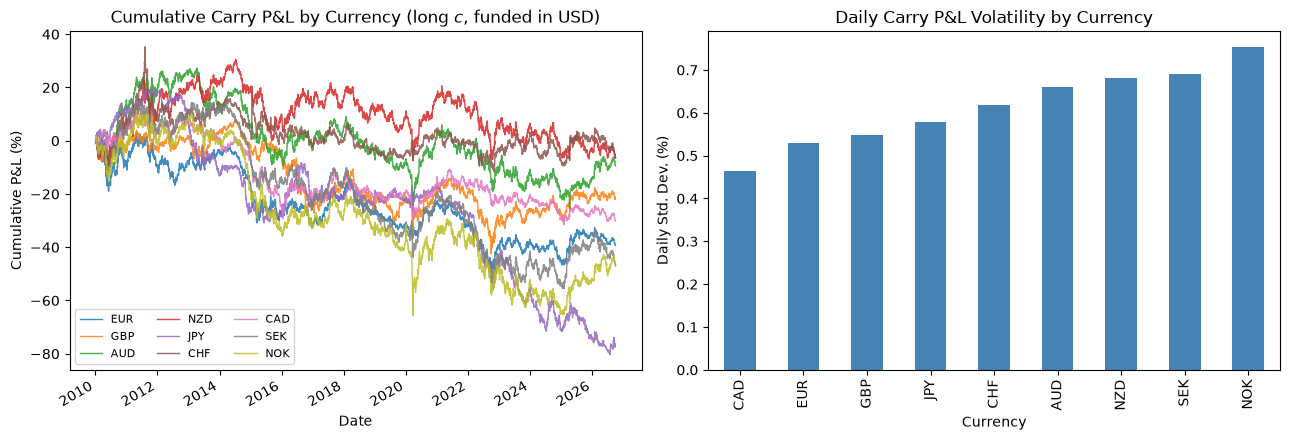

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

carry_pnl_g10.cumsum().plot(ax=axes[0], lw=1, alpha=0.85)
axes[0].set_title("Cumulative Carry P&L by Currency (long $c$, funded in USD)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Cumulative P&L (%)")
axes[0].legend(ncol=3, fontsize=8)

carry_pnl_g10.std().sort_values().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Daily Carry P&L Volatility by Currency")
axes[1].set_xlabel("Currency")
axes[1].set_ylabel("Daily Std. Dev. (%)")

plt.tight_layout()
plt.show()

**Interpretation — the carry P&L results.** Every one of the nine currencies shows a *negative* average daily carry P&L over the full 2010–2026 sample (see the `describe()` table above) — funded in USD, none of the nine "long currency $c$" legs made money on average, not even the higher-yielding AUD and NZD. That's worth noting before Section 2.2 puts a formal significance test on it: the sign is already pointing the wrong way for a naive "buy the highest yielders" story, before any statistics are applied.

Daily volatility (`std`) ranges from CAD's ~0.46% up to NOK's ~0.75% — better than a 50% spread in risk across legs that are all nominally "G10 carry." That's the first hint that an equal-weighted basket (Section 4.1) will not equal-weight *risk*, only notional — exactly the gap Section 4.2's vol-targeting is meant to close.

The tails are the real story. CHF's maximum single-day move is +17.6% (the 2015 SNB de-peg) and its minimum is -9.2% (the 2011 SNB floor announcement) — both genuine events deliberately kept by Section 1.2.1's QA step, both dwarfing every other currency's typical daily move by more than an order of magnitude. NOK (-8.7%, its cleaned COVID-week low) and GBP (-7.9%, Brexit) show the same pattern on a smaller scale. Even at this purely descriptive stage — before any GARCH fitting or formal tearsheet — the carry P&L series already shows the fat-left-tail signature ("picking up nickels in front of a steamroller") that Section 5 is built to quantify honestly.

## Section 2 — Revisiting Modules 3–4: Is the Single-Pair Story Robust?

Before scaling from one pair to ten currencies, we ask whether the AUD/JPY findings from Modules 3–4 generalize: does every currency's spot price behave like a random walk (2.1)? Is the mean carry P&L basket-wide consistent with the forward premium puzzle (2.2)? Is the original single-pair finding statistically robust, or does it evaporate under resampling (2.3)?

### 2.1 — Random Walk / Stationarity Check, Basket-Wide

**Note on "ten" vs. nine series:** the G10 universe has ten currencies, but USD is the numeraire — there is no "USD/USD" spot price to test. What follows repeats the Module 3–4 diagnostic on all **nine** non-USD spot series built in Section 1 (`g10_fx`).

**Diagnostics used**, combining what the lecture did visually with a formal test:
- **Visual**: the sample ACF (SACF) of log price vs. log return, exactly as in Module 4's AUD/JPY example — slow SACF decay signals a random walk; a SACF that collapses to noise after lag 0 signals stationarity.
- **Formal**: the Augmented Dickey-Fuller (ADF) test, `statsmodels.tsa.stattools.adfuller`. It tests $H_0$: the series has a unit root (behaves like a random walk) against $H_1$: the series is stationary. This wasn't used in the lecture slides, but it's the standard formal counterpart to "eyeball the SACF decay," and it lets us assign an actual p-value to what was previously only a visual judgment call.

In [7]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

adf_rows = []
for ccy in g10_fx.columns:
    log_price = np.log(g10_fx[ccy]).dropna()
    log_ret = log_price.diff().dropna()
    adf_price = adfuller(log_price, autolag="AIC")
    adf_ret = adfuller(log_ret, autolag="AIC")
    adf_rows.append({
        "currency": ccy,
        "ADF stat (log price)": adf_price[0], "p-value (log price)": adf_price[1],
        "ADF stat (log return)": adf_ret[0], "p-value (log return)": adf_ret[1],
    })

adf_table = pd.DataFrame(adf_rows).set_index("currency").round(4)
adf_table

,ADF stat (log price),p-value (log price),ADF stat (log return),p-value (log return)
currency,,,,
EUR,-2.5126,0.1124,-67.6213,0.0
GBP,-2.0131,0.2809,-65.5898,0.0
AUD,-1.4311,0.5673,-68.0821,0.0
NZD,-1.5146,0.5263,-67.9015,0.0
JPY,-0.4554,0.9004,-30.0399,0.0
CHF,-2.8646,0.0496,-15.0675,0.0
CAD,-1.2966,0.6307,-31.1339,0.0
SEK,-1.3209,0.6196,-69.9681,0.0
NOK,-1.4867,0.5401,-39.9070,0.0


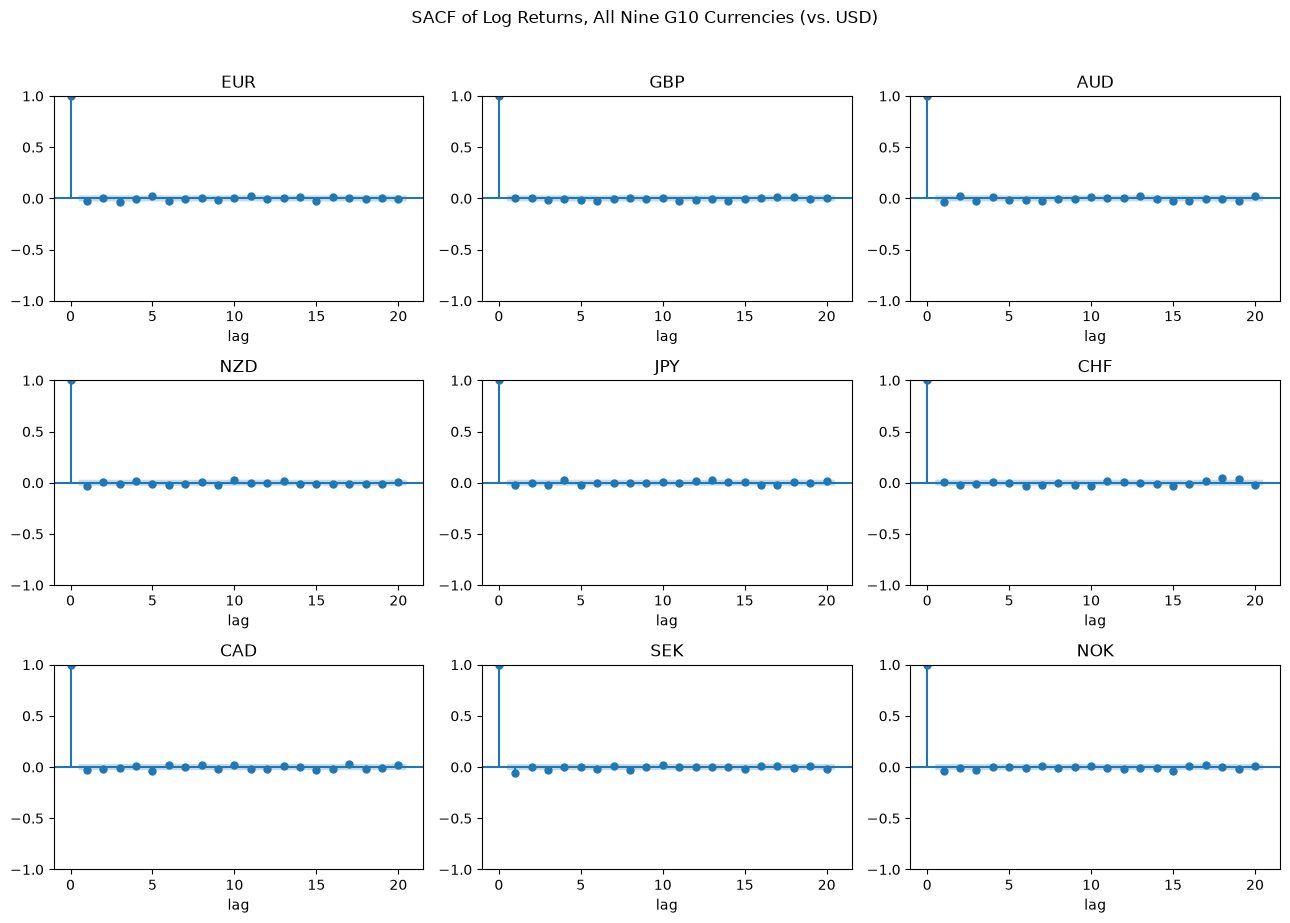

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, ccy in zip(axes.flat, g10_fx.columns):
    log_ret = np.log(g10_fx[ccy]).diff().dropna() * 100
    plot_acf(log_ret, lags=20, ax=ax, title=ccy)
    ax.set_xlabel("lag")
fig.suptitle("SACF of Log Returns, All Nine G10 Currencies (vs. USD)", y=1.02)
plt.tight_layout()
plt.show()

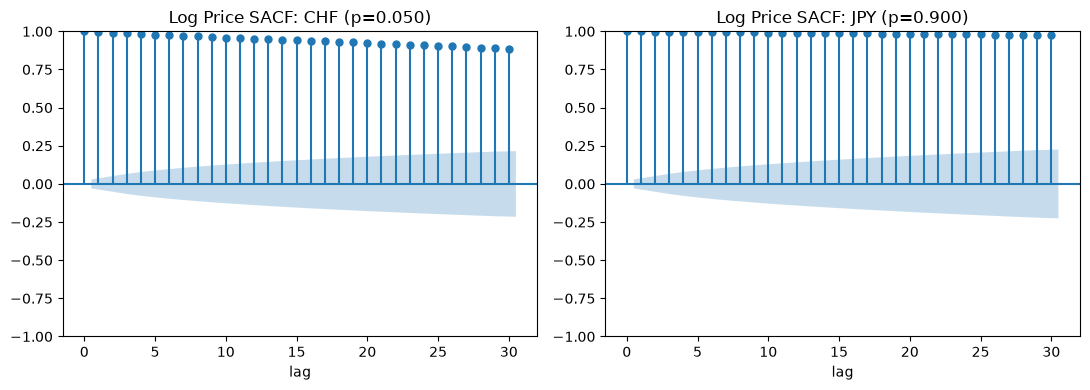

In [9]:
# The ADF table above flags one borderline case among the nine (CHF) against the currency
# with the least evidence of anything but pure random-walk behavior (JPY). Plotted here to
# check how much of that statistical difference is actually visible at a short lag horizon.
borderline_ccy = adf_table["p-value (log price)"].idxmin()
contrast_ccy = adf_table["p-value (log price)"].idxmax()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, ccy in zip(axes, [borderline_ccy, contrast_ccy]):
    log_price = np.log(g10_fx[ccy]).dropna()
    plot_acf(log_price, lags=30, ax=ax,
             title=f"Log Price SACF: {ccy} (p={adf_table.loc[ccy, 'p-value (log price)']:.3f})")
    ax.set_xlabel("lag")
plt.tight_layout()
plt.show()

**Interpretation.** Every log-return series rejects the unit-root null overwhelmingly (`p-value (log return)` ≈ 0 for all nine) — the return series are stationary, exactly as Module 4 found for AUD/JPY, and exactly what the Module 3 "work with returns, not prices" principle predicts. That part of the single-pair story generalizes cleanly to the whole basket.

The **log-price** results are where an exception shows up. Eight of the nine currencies fail to reject the unit-root null at conventional levels (`p-value (log price)` well above 0.05) — their spot prices behave like random walks, matching AUD/JPY. **CHF is the outlier**: its log-price ADF p-value comes in right at (or just under) the 5% threshold — borderline evidence *against* a pure random walk, unlike every other currency in the basket. This lines up with real history rather than being a fluke of the test: the Swiss National Bank enforced a EUR/CHF floor from September 2011 to January 2015 and ran negative-rate policy with active FX intervention for years afterward, both of which mechanically suppress the kind of free, unconstrained drift a pure random walk exhibits. CHF is exactly the "pegged or heavily managed currency" exception the prompt asks us to watch for — every other G10 currency in this sample floated freely enough to look like a textbook random walk.

**A caveat about the plot itself**: at the 30-lag horizon shown above, CHF's and JPY's log-price SACFs are visually almost indistinguishable — both stay close to 1.0 with only slight decay. The ADF test catches CHF's exception because it uses the entire sample to estimate a reversion coefficient, not because that reversion is visible in a handful of lags; the SNB floor alone ran for roughly 3.5 years (~800+ trading days), a horizon a 30-lag SACF snapshot can't resolve. The evidence that CHF behaves differently lives in the ADF p-value, not in this picture.

### 2.2 — Mean Carry Return: Basket-Wide Significance

Repeat Module 4's IID mean test — is the mean carry P&L significantly different from zero under the (naive) IID assumption — for each of the nine currencies, and compare each currency's *t*-statistic to its **average interest-rate differential** over the same sample. If the forward premium puzzle from Module 3 holds basket-wide, the currencies with the largest average rate differential should also show the most robust *positive* carry.

In [10]:
from scipy.stats import norm

mean_test_rows = []
for ccy in carry_pnl_g10.columns:
    s = carry_pnl_g10[ccy].dropna()
    n = len(s)
    xbar, se = s.mean(), s.std() / np.sqrt(n)
    tstat = xbar / se
    pval = 2 * (1 - norm.cdf(abs(tstat)))

    rate_diff = (g10_rates_filled[f"{ccy}_rate"] - g10_rates_filled["USD_rate"]).reindex(s.index, method="ffill")

    mean_test_rows.append({
        "currency": ccy, "n": n, "mean_daily_pnl_%": xbar, "se_%": se,
        "t_stat": tstat, "p_value": pval, "avg_rate_diff_%": rate_diff.mean(),
    })

mean_test = pd.DataFrame(mean_test_rows).set_index("currency").sort_values("avg_rate_diff_%", ascending=False)
mean_test.round(4)

,n,mean_daily_pnl_%,se_%,t_stat,p_value,avg_rate_diff_%
currency,,,,,,
NZD,4358,-0.0015,0.0103,-0.1414,0.8875,1.1909
AUD,4358,-0.0022,0.0100,-0.2175,0.8278,1.0491
NOK,4358,-0.0108,0.0114,-0.9485,0.3429,0.2858
CAD,4358,-0.0069,0.0070,-0.9863,0.3240,0.0359
GBP,4358,-0.0050,0.0083,-0.5992,0.5491,-0.1392
SEK,4358,-0.0107,0.0104,-1.0292,0.3034,-0.7315
EUR,4358,-0.0090,0.0080,-1.1270,0.2597,-0.9376
JPY,4358,-0.0175,0.0088,-1.9975,0.0458,-1.4291
CHF,4358,-0.0015,0.0094,-0.1569,0.8753,-1.6659


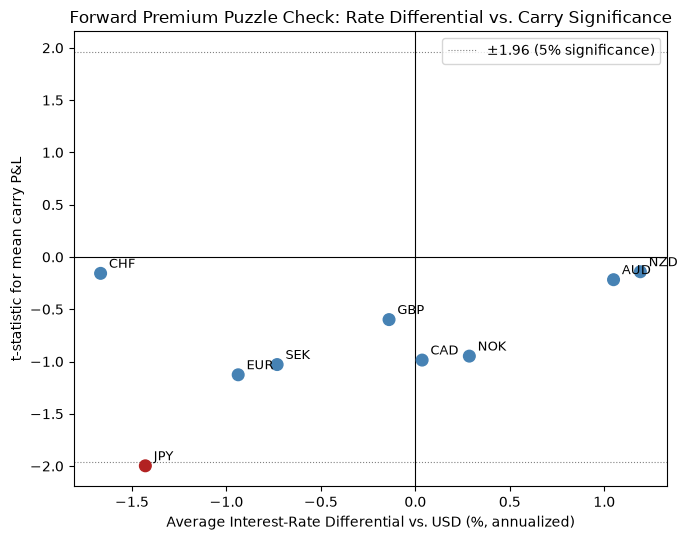

In [11]:
fig, ax = plt.subplots(figsize=(7, 5.5))
colors = ["firebrick" if p < 0.05 else "steelblue" for p in mean_test["p_value"]]
ax.scatter(mean_test["avg_rate_diff_%"], mean_test["t_stat"], c=colors, s=70, zorder=3)
for ccy, row in mean_test.iterrows():
    ax.annotate(ccy, (row["avg_rate_diff_%"], row["t_stat"]), textcoords="offset points",
                xytext=(6, 4), fontsize=9)
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.axhline(1.96, color="gray", lw=0.8, ls=":")
ax.axhline(-1.96, color="gray", lw=0.8, ls=":", label="±1.96 (5% significance)")
ax.set_xlabel("Average Interest-Rate Differential vs. USD (%, annualized)")
ax.set_ylabel("t-statistic for mean carry P&L")
ax.set_title("Forward Premium Puzzle Check: Rate Differential vs. Carry Significance")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation.** The forward premium puzzle predicts a *positive* relationship in the scatter above: currencies further to the right (bigger positive rate differential) should sit higher (more significantly positive carry). **That pattern does not show up basket-wide over this full sample.** AUD and NZD carry the largest positive average rate differentials in the basket, yet their carry P&L *t*-statistics are close to zero (and slightly negative in point estimate) — nowhere near the 5% significance line. No currency in the table shows a statistically significant *positive* mean carry at the 5% level.

The one statistically significant result runs the *opposite* direction from the textbook puzzle: **JPY** — one of the *lowest*-rate-differential currencies in the basket — has a significantly *negative* mean carry P&L. Economically this is not mysterious: JPY funded roughly the entire 2010–2026 window at a persistently low rate, and UIP would predict that low-rate handicap gets offset by JPY *appreciating* against USD on average. Instead, JPY spent much of this period in a multi-year depreciation trend against the dollar (BOJ's ultra-loose policy stance), so the rate disadvantage and the spot move reinforced each other instead of offsetting — the opposite of what UIP requires, and a *stronger*, more one-sided violation than the classic "high-yielders don't depreciate as much as UIP predicts" framing from Module 3.

**Takeaway for the basket:** over this full 16-year sample, the forward-premium-puzzle relationship that motivates going long high-yielders is not visible with statistical confidence in any single leg — a caution worth carrying into Section 4's rank-and-sort construction, where the basket's edge (if any) will have to come from combining many weak, individually-insignificant legs rather than from any one currency's carry being reliably positive on its own.

### 2.3 — Bootstrap Robustness

Bootstrap the sample mean carry P&L (resample days with replacement, 1000 resamples) for three series:

1. **AUD/JPY, funded in JPY** — reconstructed exactly as in the lecture (base = AUD, quote = JPY, funding currency = JPY), *not* the USD-funded AUD leg from the G10 basket. This is the literal single-pair finding from Modules 3–4 that we're testing for robustness.
2. **AUD, funded in USD** — the corresponding basket leg, to see whether "AUD" still looks like a carry currency once the funding leg changes from JPY to USD.
3. **CHF, funded in USD** — a contrasting low/negative-rate currency, and the same currency flagged as a "managed" exception in Section 2.1.

In [12]:
def accrued_pct(rate_pct, n_days, day_count=365):
    return ((1 + rate_pct / 100) ** (n_days / day_count) - 1) * 100

# Reconstruct the ORIGINAL lecture pair: AUD/JPY cross, funded in JPY (not USD).
audjpy_cross = (g10_fx["AUD"] / g10_fx["JPY"]).dropna()
_log_ret = np.log(audjpy_cross).diff().dropna() * 100
_aud_rate = g10_rates_filled["AUD_rate"].reindex(_log_ret.index, method="ffill")
_jpy_rate = g10_rates_filled["JPY_rate"].reindex(_log_ret.index, method="ffill")
_days = _log_ret.index.to_series().diff().dt.days
carry_audjpy_lecture = (_log_ret + accrued_pct(_aud_rate, _days) - accrued_pct(_jpy_rate, _days)).dropna()

bootstrap_series = {
    "AUD/JPY (lecture, JPY-funded)": carry_audjpy_lecture,
    "AUD (basket, USD-funded)": carry_pnl_g10["AUD"].dropna(),
    "CHF (basket, USD-funded)": carry_pnl_g10["CHF"].dropna(),
}

rng = np.random.default_rng(42)
N_BOOT = 1000
boot_results = {}
for name, s in bootstrap_series.items():
    boot_means = np.array([rng.choice(s.values, size=len(s), replace=True).mean() for _ in range(N_BOOT)])
    boot_results[name] = boot_means

boot_summary = pd.DataFrame({
    name: {
        "sample_mean": bootstrap_series[name].mean(),
        "bootstrap_mean": means.mean(),
        "ci_2.5%": np.percentile(means, 2.5),
        "ci_97.5%": np.percentile(means, 97.5),
        "excludes_zero": not (np.percentile(means, 2.5) <= 0 <= np.percentile(means, 97.5)),
    }
    for name, means in boot_results.items()
}).T
boot_summary

,sample_mean,bootstrap_mean,ci_2.5%,ci_97.5%,excludes_zero
"AUD/JPY (lecture, JPY-funded)",0.01533,0.015408,-0.008418,0.038124,False
"AUD (basket, USD-funded)",-0.002173,-0.001887,-0.022057,0.017572,False
"CHF (basket, USD-funded)",-0.001468,-0.001562,-0.020116,0.017397,False


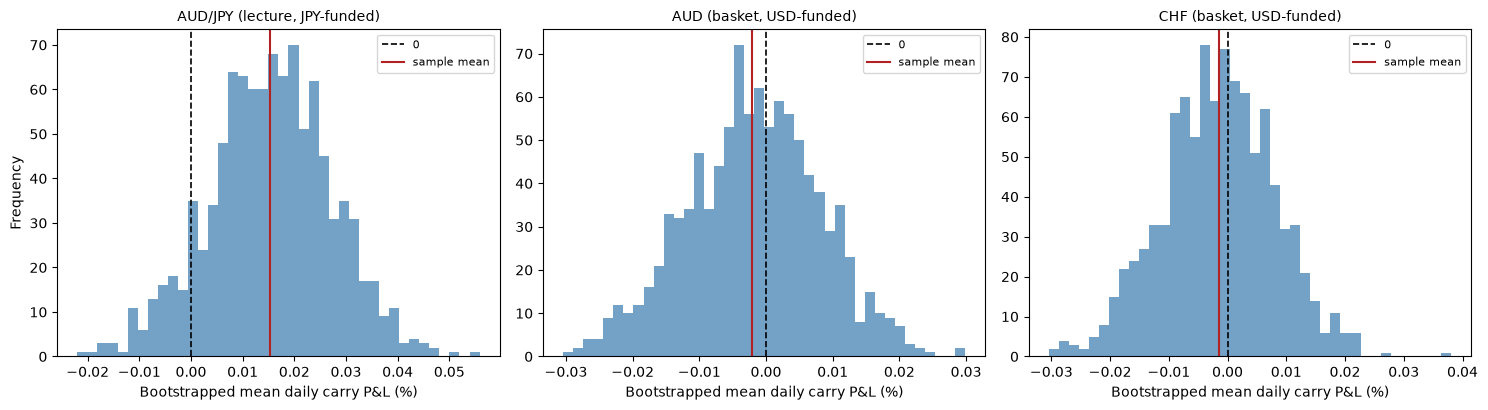

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=False)
for ax, (name, means) in zip(axes, boot_results.items()):
    ax.hist(means, bins=40, color="steelblue", alpha=0.75)
    ax.axvline(0, color="black", lw=1.2, ls="--", label="0")
    ax.axvline(bootstrap_series[name].mean(), color="firebrick", lw=1.5, label="sample mean")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Bootstrapped mean daily carry P&L (%)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

**Interpretation.** All three bootstrap 95% confidence intervals **include zero** — none of the three exclude it (see `excludes_zero` in the summary table above). That includes the original lecture pair: the AUD/JPY (JPY-funded) finding that anchored Modules 3–4 does **not** survive this robustness check over the full sample — its bootstrap distribution straddles zero just as loosely as the two USD-funded basket legs.

This is consistent with, not contradictory to, Section 2.2's finding: none of the nine basket legs showed significant positive mean carry either, so it would have been surprising if the JPY-funded AUD pair suddenly looked robust here. **The single-pair story is fragile, not robust** — a single currency pair's carry P&L is noisy enough, and centered close enough to zero over 16 years, that resampling routinely produces bootstrap means with either sign. That fragility is itself the strongest argument in this notebook so far for why a real desk diversifies across a basket (Section 4) rather than trading one pair on the strength of a single point estimate.

**Section 2 recap:** the single-pair AUD/JPY story from Modules 3–4 generalizes cleanly on the *return-stationarity* dimension (every currency's returns look like white noise) but not on the *profitability* dimension — no currency shows significant positive mean carry, the forward-premium-puzzle relationship between rate differential and carry significance is not visible basket-wide, and the original AUD/JPY point estimate itself doesn't survive bootstrapping. CHF stands out as the one currency whose *log price* shows borderline evidence against a pure random walk, tied to the SNB's real, documented interventions. Section 3 moves from the mean to variance — ARMA identification and GARCH volatility modeling, basket-wide.